# BERT 핵심 구조와 문맥 표현

BERT는 Transformer의 **Encoder만 쌓은 양방향 사전학습 언어 모델**이다. 문장의 모든 실제 토큰이 서로를 참고하도록 Self-Attention을 계산하므로 같은 단어라도 주변 문장에 따라 다른 벡터가 된다. 앞 단원에서 배운 WordPiece는 문자열을 BERT가 처리할 토큰 ID로 바꾸는 입구이며, BERT는 그 ID를 문맥이 담긴 연속 벡터로 변환한다.

이 노트북은 입력 형식, 양방향 문맥화, MLM을 한 흐름으로 연결한다. BERT Encoder 자체는 다음 단어를 왼쪽에서 오른쪽으로 생성하는 자동회귀 모델이 아니라는 점을 먼저 구분해야 한다.


## BERT 입력과 문맥 벡터

그림의 청록 막대는 각 토큰 위치의 문맥 벡터이고, 아래 `1 1 1 1 0`은 별도의 `attention_mask`이다. Self-Attention 연결은 실제 토큰 사이에만 그려져 있으며 `[PAD]`는 key로 참고하지 않는다.

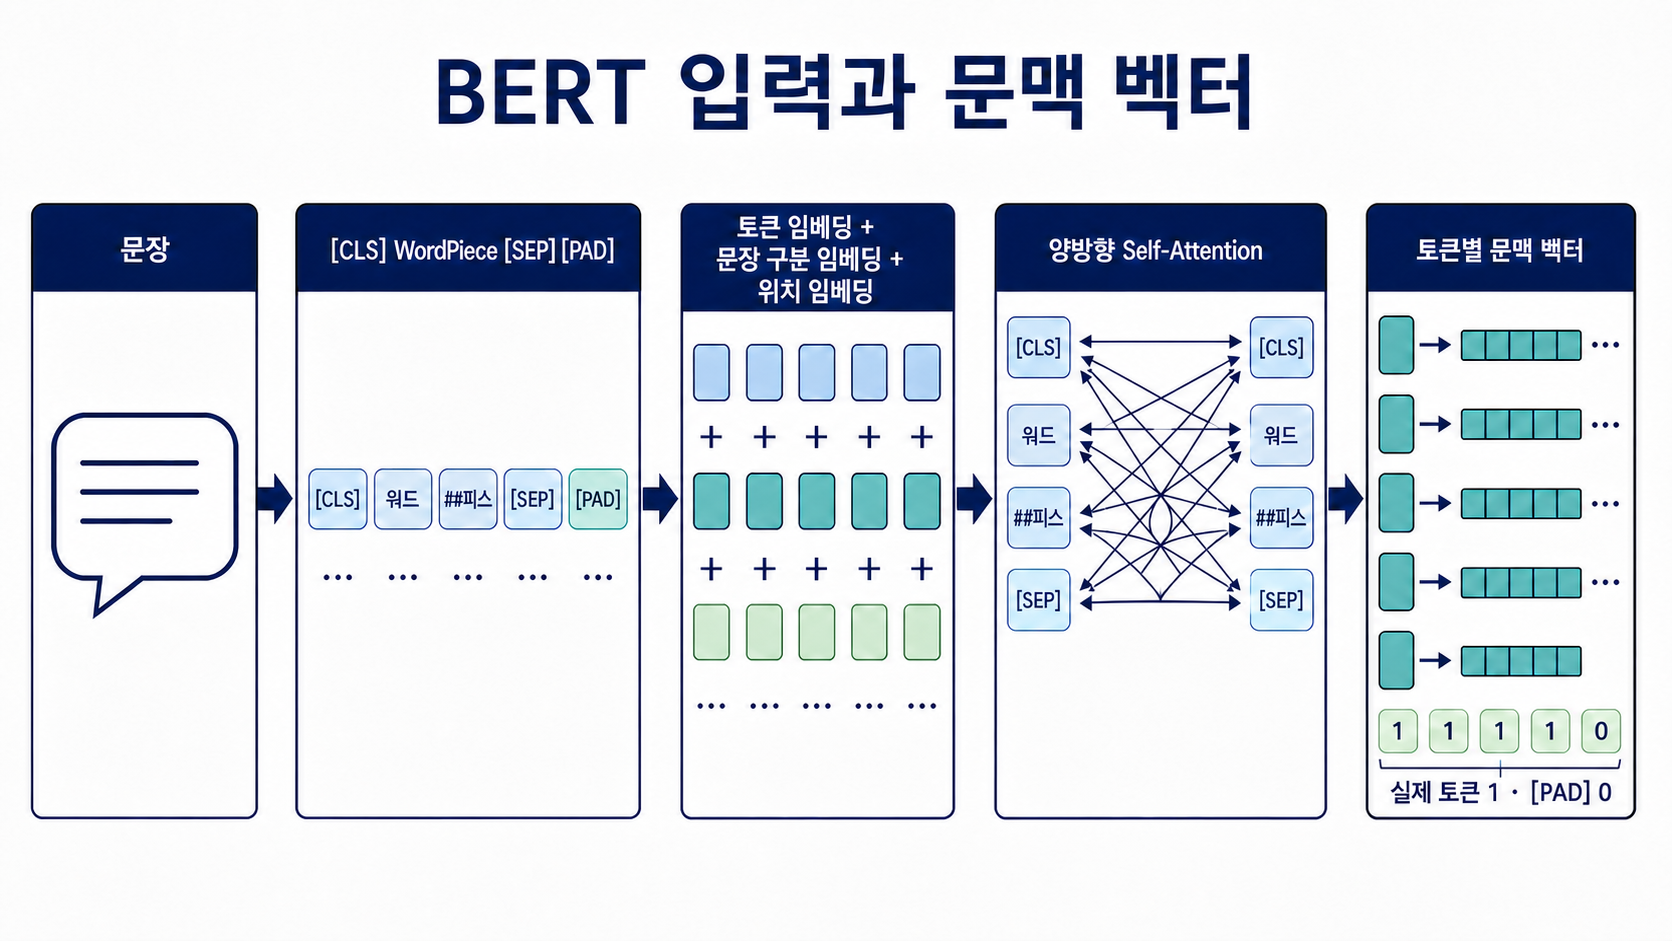


## 1. WordPiece에서 BERT 입력까지

토크나이저는 문장을 WordPiece 토큰으로 분리한 뒤 `[CLS]`, `[SEP]`, `[PAD]` 같은 특수 토큰을 배치한다. `input_ids`는 어휘 사전 번호, `attention_mask`는 실제 토큰과 패딩의 구분, `token_type_ids`는 문장 A와 문장 B의 구분이다. 모델과 토크나이저가 서로 다른 체크포인트를 사용하면 같은 ID가 다른 토큰을 뜻할 수 있으므로 반드시 함께 맞춘다.

BERT가 처음 받는 벡터는 토큰 임베딩, 문장 구분 임베딩, 위치 임베딩을 더한 결과이다. `attention_mask`는 이 합에 포함되는 임베딩이 아니라 Self-Attention에서 `[PAD]`를 참고하지 않도록 막는 제어 정보이다.


In [1]:
from transformers import AutoModelForMaskedLM, AutoTokenizer
import torch
import torch.nn.functional as F

MODEL_ID = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# pooler·seq_relationship UNEXPECTED는 MLM에 사용하지 않는 NSP 계층을 제외했다는 정상 안내이다.
model = AutoModelForMaskedLM.from_pretrained(MODEL_ID)
model.eval()

print("mask token/id:", tokenizer.mask_token, tokenizer.mask_token_id)
print("hidden size:", model.config.hidden_size)
print("vocabulary size:", model.config.vocab_size)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mask token/id: [MASK] 4
hidden size: 768
vocabulary size: 32000


### 토큰화 배치 확인

준비한 토크나이저로 의미가 다른 두 `사과` 문장을 같은 배치로 변환한다. 서로 다른 길이는 `[PAD]`와 `attention_mask`로 맞추고, 실제 WordPiece와 tensor shape를 함께 확인한다.


In [2]:
sentences = [
    "나는 사과를 먹었다.",
    "그는 자신의 실수를 사과했다.",
]

# attention_mask에서 실제 토큰은 1, [PAD]는 0이다.
encoded = tokenizer(sentences, padding=True, return_tensors="pt")

for key, value in encoded.items():
    print(f"{key:16s} shape={tuple(value.shape)}")
print("tokens[0]:", tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))
print("tokens[1]:", tokenizer.convert_ids_to_tokens(encoded["input_ids"][1]))
print("attention_mask:", encoded["attention_mask"].tolist())


input_ids        shape=(2, 12)
token_type_ids   shape=(2, 12)
attention_mask   shape=(2, 12)
tokens[0]: ['[CLS]', '나', '##는', '사과', '##를', '먹', '##었', '##다', '.', '[SEP]', '[PAD]', '[PAD]']
tokens[1]: ['[CLS]', '그', '##는', '자신', '##의', '실수', '##를', '사과', '##했', '##다', '.', '[SEP]']
attention_mask: [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


## 2. 양방향 Self-Attention과 문맥 벡터

Encoder의 각 층에서 토큰은 문장 왼쪽과 오른쪽의 실제 토큰을 모두 참고한다. 따라서 두 문장의 `사과`는 같은 토큰 ID와 같은 토큰 임베딩에서 시작하지만, `먹었다`와 `실수`라는 주변 정보가 섞인 뒤에는 서로 다른 문맥 벡터가 된다.

마지막 은닉 상태의 shape은 `(B, T, H)`이다. `B`는 문장 수, `T`는 패딩을 포함한 토큰 길이, `H`는 모델의 은닉 차원이다. BERT를 통과하기 전 `[CLS]`는 단순한 특수 토큰 임베딩일 뿐 문장 요약이 아니다. 각 Self-Attention 층에서 `[CLS]` 위치의 Query가 다른 실제 토큰의 Key와 Value를 참고하면서 0번 위치 벡터가 반복해서 갱신된다. 모든 Encoder 층을 통과한 뒤에야 다른 토큰 정보가 반영된 `(B, H)` 벡터가 된다.

이 Encoder 출력만으로 긍정이나 부정 점수가 자동으로 생기지는 않는다. 다음 전이학습 노트북에서 분류 head를 붙이고 정답 loss로 학습해야 `[CLS]` 벡터가 문장 분류에 유용하도록 조정된다. 토큰 분류에서는 `[CLS]` 하나가 아니라 전체 `(B, T, H)`를 사용한다.


In [3]:
with torch.no_grad():
    outputs = model(**encoded, output_hidden_states=True)

last_hidden = outputs.hidden_states[-1]  # (B, T, H): 문장, 토큰 위치, 은닉 특성 순서이다.
# 각 문장의 토큰 ID를 문자열 토큰으로 복원하여 `사과`의 위치를 찾는다.
token_lists = [
    tokenizer.convert_ids_to_tokens(row) for row in encoded["input_ids"]
]
apple_positions = [tokens.index("사과") for tokens in token_lists]
# 문장별 `사과` 위치의 768차원 문맥 벡터를 선택해 하나의 tensor로 묶는다.
apple_vectors = torch.stack(
    [last_hidden[row, position] for row, position in enumerate(apple_positions)]
)
context_similarity = F.cosine_similarity(
    apple_vectors[0], apple_vectors[1], dim=0
).item()

cls_vectors = last_hidden[:, 0, :]  # 모든 Encoder 층을 지난 0번 위치 결과이다.
print("last_hidden shape:", tuple(last_hidden.shape))
print("CLS vectors shape:", tuple(cls_vectors.shape))
print("사과 positions:", apple_positions)
print(f"contextual 사과 cosine similarity: {context_similarity:.4f}")
print("CLS는 다음 노트북의 classification head를 거쳐야 분류 점수가 된다.")


last_hidden shape: (2, 12, 768)
CLS vectors shape: (2, 768)
사과 positions: [3, 7]
contextual 사과 cosine similarity: 0.5000
CLS는 다음 노트북의 classification head를 거쳐야 분류 점수가 된다.


## 3. MLM으로 양방향 문맥을 사전학습하기

MLM은 입력 토큰 일부를 `[MASK]`로 가리고 그 위치의 원래 토큰을 맞히는 학습 목표이다. `[MASK]`의 왼쪽과 오른쪽 문맥을 동시에 사용할 수 있으므로 BERT가 양방향 표현을 익힐 수 있다. 실제 사전학습에서는 일부 선택 토큰을 그대로 두거나 임의 토큰으로 바꾸는 전략도 사용하지만, 여기서는 핵심 경로만 확인한다.

모델은 `[MASK]` 위치마다 어휘 크기 `V`의 로짓을 출력한다. 전체 MLM 로짓 shape은 `(B, T, V)`이며, softmax 뒤 가장 큰 확률의 토큰을 후보로 해석한다.


In [4]:
masked_text = f"서울은 대한민국의 {tokenizer.mask_token}이다."
masked_inputs = tokenizer(masked_text, return_tensors="pt")

with torch.no_grad():
    masked_outputs = model(**masked_inputs)

# [MASK] 위치의 어휘 로짓만 선택한다.
mask_position = (
    masked_inputs["input_ids"][0] == tokenizer.mask_token_id
).nonzero(as_tuple=True)[0].item()
mask_logits = masked_outputs.logits[0, mask_position]
top_probabilities, top_ids = torch.softmax(mask_logits, dim=-1).topk(5)

print("MLM logits shape:", tuple(masked_outputs.logits.shape))
for probability, token_id in zip(top_probabilities, top_ids):
    token = tokenizer.convert_ids_to_tokens(int(token_id))
    print(f"{token:12s} probability={float(probability):.4f}")


MLM logits shape: (1, 9, 32000)
수도           probability=0.2795
중심           probability=0.2414
심장           probability=0.2320
상징           probability=0.0510
강남           probability=0.0160


## 4. 특수 토큰과 사용처

`[CLS]`는 문장 전체를 대표하도록 사용하는 첫 위치이고, `[SEP]`는 문장 경계, `[PAD]`는 배치 길이 정렬, `[MASK]`는 MLM 학습에 사용한다. 특수 토큰의 의미는 모델 구조만으로 자동 보장되는 것이 아니라 사전학습 방식과 downstream 학습 설계가 함께 만든다.

BERT의 대표 사용처는 문장 분류, 토큰 분류, 질의응답, 의미 유사도 등이다. 다음 노트북에서는 사전학습 BERT에 분류 head를 붙이고 작은 감성 분류 데이터로 전이학습 경로를 확인한다.


## BERT 전체 흐름 정리

문자열이 WordPiece와 모델 입력을 거쳐 문맥 벡터로 변환되고, 목적에 맞는 head에서 MLM이나 문장 분류 결과로 바뀌는 흐름이다.

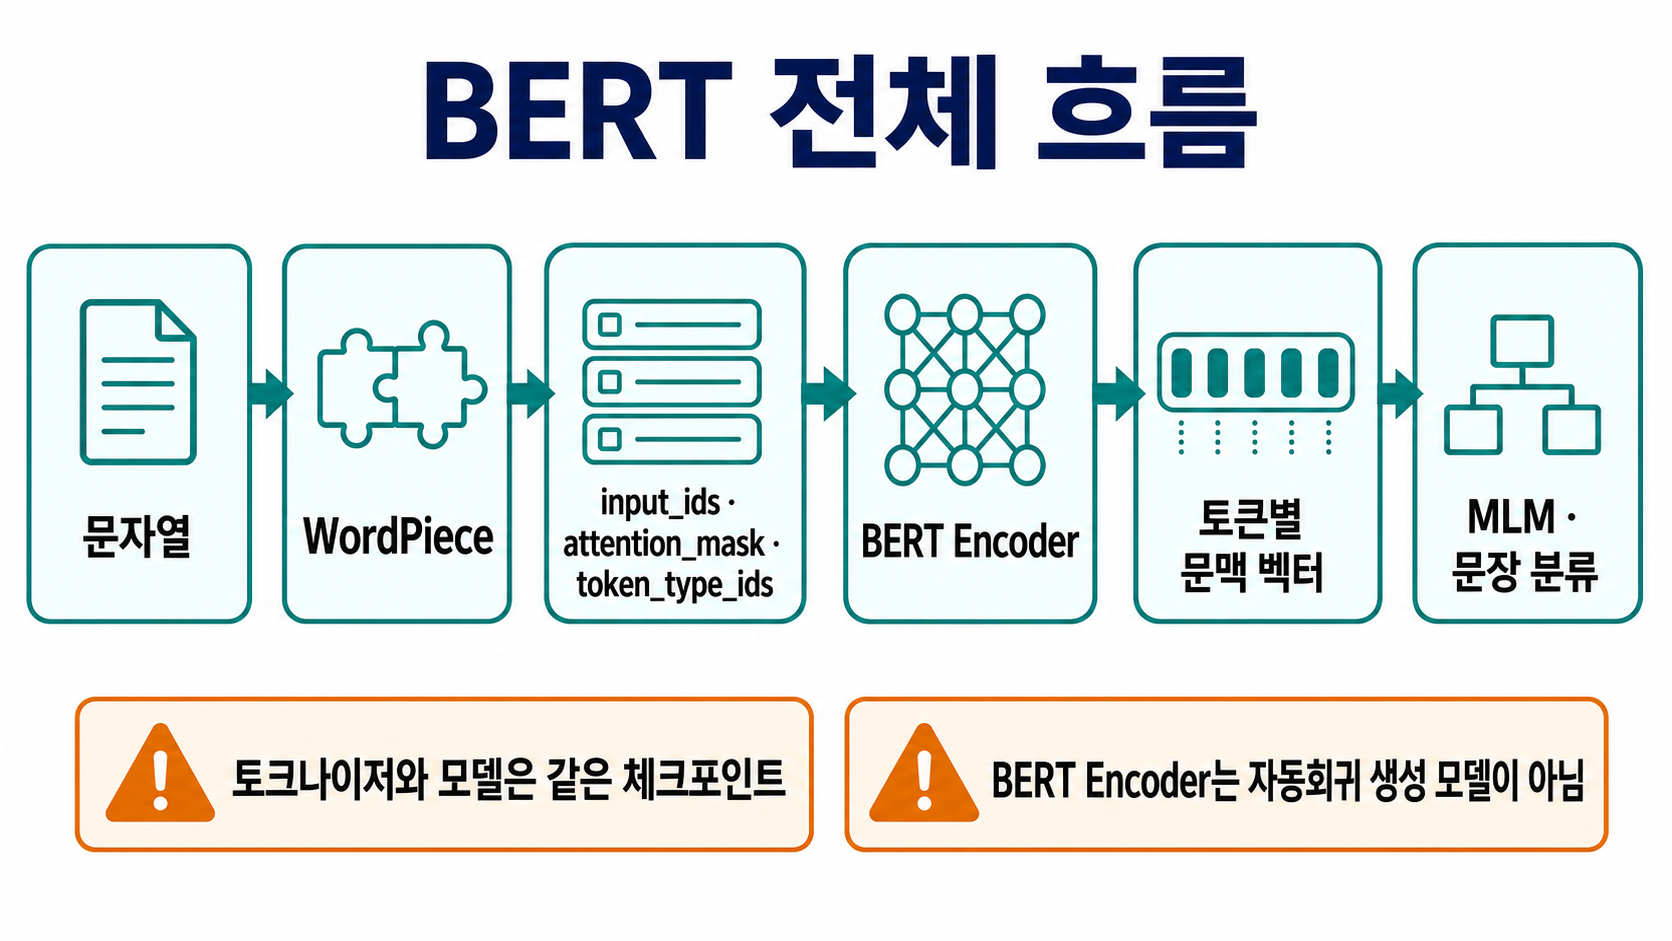
